In [1]:
import pandas as pd

chunks = []

for chunk in pd.read_json("indy_philly_restaurant_reviews.json", lines=True, chunksize=100000):
    
    filtered = chunk[
        (chunk["city"].isin(["Indianapolis", "Philadelphia"])) &
        (chunk["categories"].str.contains("Restaurant", na=False))
    ]
    
    chunks.append(filtered)

df_ind_pa_restaurants = pd.concat(chunks)

print(df_ind_pa_restaurants.shape)

df_ind_pa_restaurants.to_json(
    "business_ind_pa_restaurants.json",
    orient="records",
    lines=True
)

(937886, 20)


In [2]:
print(df_ind_pa_restaurants.columns.tolist())


['business_id', 'name', 'address', 'city', 'state', 'postal_code', 'latitude', 'longitude', 'stars', 'review_count', 'is_open', 'attributes', 'categories', 'hours', 'review_id', 'user_id', 'useful', 'funny', 'cool', 'date']


In [3]:
df_ind_pa_restaurants.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours,review_id,user_id,useful,funny,cool,date
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",BXQcBN0iAi1lAUxibGLFzA,6_SpY41LIHZuIaiDs5FMKA,0,0,1,2014-05-26 01:09:53
1,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",uduvUCvi9w3T2bSGivCfXg,tCXElwhzekJEH6QJe3xs7Q,3,1,2,2013-10-05 15:19:06
2,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,5,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",a0vwPOqDXXZuJkbBW2356g,WqfKtI-aGMmvbA9pPUxNQQ,0,0,0,2013-10-25 01:34:57
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,5,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",MKNp_CdR2k2202-c8GN5Dw,3-1va0IQfK-9tUMzfHWfTA,5,0,5,2018-05-20 17:58:57
4,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",D1GisLDPe84Rrk_R4X2brQ,EouCKoDfzaVG0klEgdDvCQ,2,1,1,2013-10-25 02:31:35


In [4]:
# Deduplicate to one row per business FIRST
df_businesses = df_ind_pa_restaurants.drop_duplicates(subset='business_id')

# Stricter restaurant filter — must contain 'Restaurant' in categories
df_restaurants_only = df_businesses[
    df_businesses['categories'].str.contains('Restaurant', na=False)
]

# Bayesian score
C = df_restaurants_only['stars'].mean()
m = df_restaurants_only['review_count'].quantile(0.70)

df_restaurants_only = df_restaurants_only.copy()
df_restaurants_only['bayes_score'] = (
    (df_restaurants_only['review_count'] / (df_restaurants_only['review_count'] + m)) * df_restaurants_only['stars'] +
    (m / (df_restaurants_only['review_count'] + m)) * C
)

# Top 5 per city — now clean
top5_per_city = (
    df_restaurants_only[df_restaurants_only['is_open'] == 1]
    .sort_values('bayes_score', ascending=False)
    .groupby('city')
    .head(5)[['city', 'name', 'stars', 'review_count', 'bayes_score', 'categories']]
    .reset_index(drop=True)
)

print(top5_per_city.to_string())

           city                            name  stars  review_count  bayes_score                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               categories
0  Philadelphia         Reading Terminal Market      5          5721     4.980034  Candy Stores, Shopping, Department Stores, Fast Food, Beer, Wine & Spirits, Fruits & Veggies, Chinese, Food, Ice Cream & Frozen Yogurt, Desserts, Seafood, Health Markets, Bagels, Cheese Shops, Shopping Centers, Chocolatiers & Shops, Meat Shops, Public Markets, Food Court, Wineries, Local Flavor, Ethnic Food, Restaurants, Special

In [11]:
df_restaurants_only = df_restaurants_only[
    ~df_restaurants_only['name'].str.contains('Reading Terminal Market', na=False)
]

Original dataset was joined/merged at the review level, so each business appears once per review it received. Always drop_duplicates('business_id') before any business-level analysis.

Matrix sparsity: 99.9865%


count    7422.000000
mean        1.174347
std         0.672320
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        15.000000
Name: review_id, dtype: float64

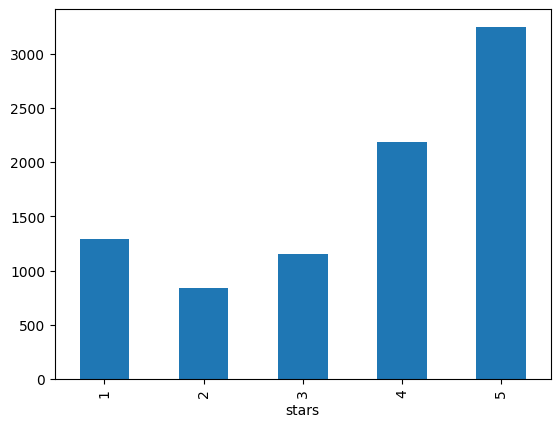

In [5]:
# Quick sparsity check
n_users = df_restaurants_only['user_id'].nunique()
n_businesses = df_restaurants_only['business_id'].nunique()
n_reviews = len(df_restaurants_only)
sparsity = 1 - (n_reviews / (n_users * n_businesses))
print(f"Matrix sparsity: {sparsity:.4%}")

# Rating distribution
df_restaurants_only['stars'].value_counts().sort_index().plot(kind='bar')

# Reviews per user
df_restaurants_only.groupby('user_id')['review_id'].count().describe()

This histogram tell us how users have rated the restaurants 
It is called positivity bias — people are far more likely to leave a review when they had a good experience. The 5-star bar is roughly 4x taller than the 2-star bar. This matters because: If we train a model on raw star ratings, it will be biased toward recommending highly-rated places regardless of fit for the user. A 3-star from a picky reviewer might actually mean the place is great.

From the given stats, median = 1.0, half of users wrote exactly 1 review
75% of the users are essentially strangers to the system. With only 1-2 reviews, you know almost nothing about their preferences. The mean of 3.3 is misleading — it's being pulled up by a small group of power users who've written hundreds of reviews.

In [6]:
# Look at raw categories values
print(df_restaurants_only['categories'].head(10).to_string())

# See how many unique category strings exist
print(f"\nUnique category strings: {df_restaurants_only['categories'].nunique()}")

0       Restaurants, Food, Bubble Tea, Coffee & Tea, B...
87      American (Traditional), Restaurants, Diners, B...
116                     Sushi Bars, Restaurants, Japanese
366                                   Korean, Restaurants
574                Steakhouses, Asian Fusion, Restaurants
594     Cocktail Bars, Bars, Italian, Nightlife, Resta...
663                       Pizza, Restaurants, Salad, Soup
704     Eatertainment, Arts & Entertainment, Brewpubs,...
770     Sports Bars, American (New), American (Traditi...
1040    Gastropubs, Cocktail Bars, Beer Bar, Bars, Res...

Unique category strings: 6202


             city         categories_list  count
7    Indianapolis  American (Traditional)    526
102  Indianapolis               Fast Food    519
20   Indianapolis                    Bars    480
241  Indianapolis              Sandwiches    436
42   Indianapolis                 Burgers    393
187  Indianapolis                 Mexican    380
6    Indianapolis          American (New)    375
217  Indianapolis                   Pizza    351
36   Indianapolis      Breakfast & Brunch    337
55   Indianapolis           Chicken Wings    212
239  Indianapolis                   Salad    202
244  Indianapolis                 Seafood    170
63   Indianapolis            Coffee & Tea    158
56   Indianapolis                 Chinese    154
157  Indianapolis                 Italian    151
332  Philadelphia                    Bars    980
591  Philadelphia              Sandwiches    929
564  Philadelphia                   Pizza    800
309  Philadelphia          American (New)    751
352  Philadelphia   

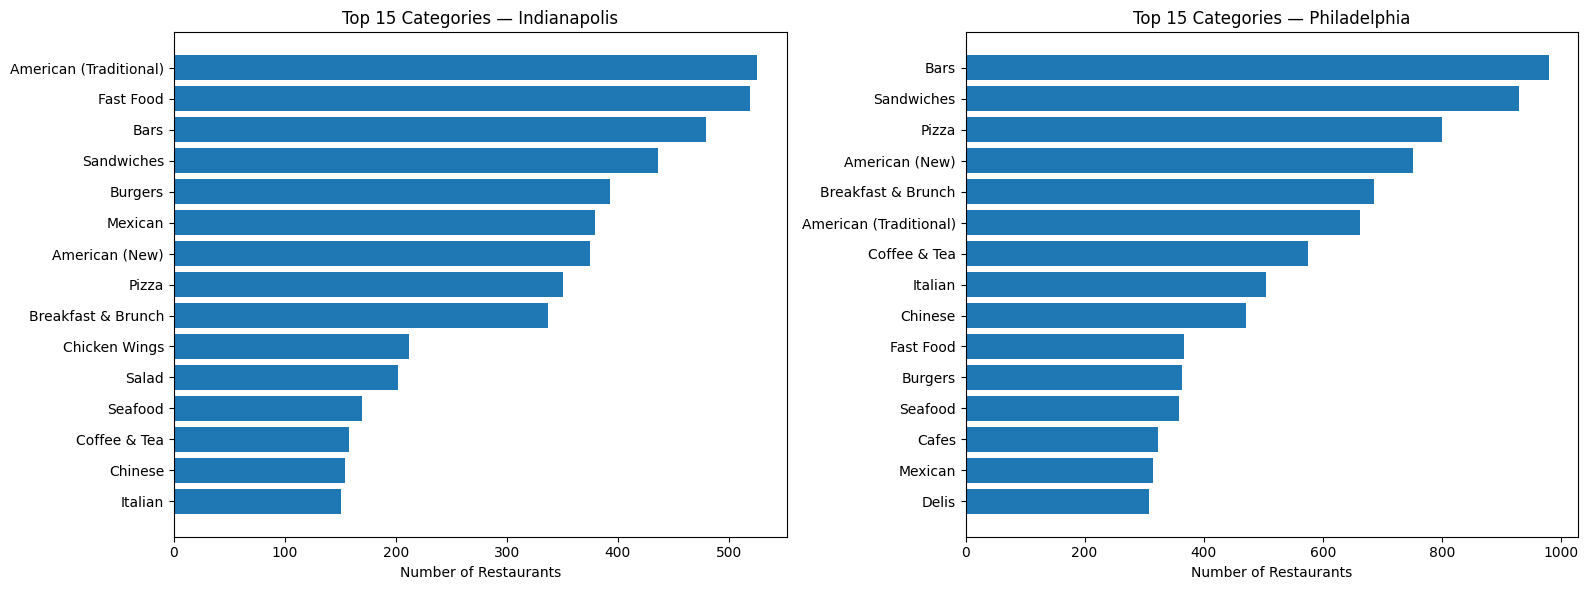

In [7]:
# Expanded junk/non-restaurant tags to remove
tags_to_remove = [
    'Restaurants', 'Food',                          # generic
    'Event Planning & Services',                     # irrelevant
    'Arts & Entertainment', 'Eatertainment',         # entertainment
    'Nightlife',                                     # too broad
    'Shopping', 'Department Stores', 'Candy Stores'  # from Reading Terminal bleed
]

# Step 1 — split
df_restaurants_only['categories_list'] = (
    df_restaurants_only['categories'].str.split(', ')
)

# Step 2 — explode
categories_exploded = df_restaurants_only.explode('categories_list')

# Step 3 — remove junk
categories_exploded = categories_exploded[
    ~categories_exploded['categories_list'].isin(tags_to_remove)
]

# Step 4 — top 15 per city
top_categories = (
    categories_exploded
    .groupby(['city', 'categories_list'])
    .size()
    .reset_index(name='count')
    .sort_values(['city', 'count'], ascending=[True, False])
    .groupby('city')
    .head(15)
)

print(top_categories.to_string())

# Step 5 — visualize
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (city, group) in zip(axes, top_categories.groupby('city')):
    ax.barh(group['categories_list'], group['count'])
    ax.set_title(f'Top 15 Categories — {city}')
    ax.set_xlabel('Number of Restaurants')
    ax.invert_yaxis()  # highest count at top

plt.tight_layout()
plt.show()

Indianapolis Breakdown
#1 is American (Traditional) with ~525 restaurants — by a clear margin. This is very on-brand for Indianapolis, a Midwest city with a strong comfort food culture.
The top 5 tells a clear story:

American (Traditional) → Fast Food → Bars → Sandwiches → Burgers


Interpretation: Indy's restaurant scene is heavily casual, comfort-food oriented. There's very little ethnic cuisine diversity in the top 10 — Chinese and Italian barely make the list at ranks 14–15. This means for Indy cold-start users, American/casual is a very safe default, but your recommender needs to work harder to surface diverse options since the data itself is less diverse.

The dropoff is steep — American Traditional (~525) vs Italian (~150) is a 3.5x gap. This is a long-tail distribution, which means a few categories dominate.

Philadelphia Breakdown
#1 is Bars with ~980 restaurants — nearly 1,000. This is the first major red flag.

Interpretation: Bars ranking #1 means a large portion of your "restaurant" dataset in Philly is actually bar-first establishments that serve food. This will pollute your recommendations — nobody asking for a restaurant wants a bar as their top result.

The rest of the top 5: Sandwiches → Pizza → American (New) → Breakfast & Brunch

Philly's profile is more urban and diverse than Indy — you see Italian, Chinese, Delis (very Philly), Seafood, Cafes all in the top 15. The x-axis goes to 1,000 vs Indy's 600, confirming again that Philly has a richer, denser dataset.

In [8]:
# Remove bar-primary establishments
bar_tags = ['Bars', 'Cocktail Bars', 'Sports Bars', 'Beer Bar', 
            'Wine Bars', 'Dive Bars', 'Gastropubs']

# Flag businesses where the FIRST category is a bar tag
df_restaurants_only['first_category'] = (
    df_restaurants_only['categories'].str.split(', ').str[0]
)

df_food_first = df_restaurants_only[
    ~df_restaurants_only['first_category'].isin(bar_tags)
]

In [9]:
# Step 1 — recreate categories_list if not already done
df_restaurants_only['categories_list'] = df_restaurants_only['categories'].str.split(', ')

# Step 2 — map each restaurant to a broad cuisine group
cuisine_map = {
    'American (Traditional)': 'American',
    'American (New)': 'American',
    'Fast Food': 'American',
    'Burgers': 'American',
    'Italian': 'Italian',
    'Pizza': 'Italian',
    'Chinese': 'Asian',
    'Japanese': 'Asian',
    'Korean': 'Asian',
    'Sushi Bars': 'Asian',
    'Mexican': 'Mexican',
    'Sandwiches': 'Casual',
    'Breakfast & Brunch': 'Casual',
    'Cafes': 'Casual',
    'Coffee & Tea': 'Casual',
    'Seafood': 'Seafood',
    'Steakhouses': 'Steakhouse',
    'Delis': 'Casual',
    'Chicken Wings': 'American',
    'Salad': 'Casual',
}

def assign_cuisine(categories_list):
    if not isinstance(categories_list, list):
        return 'Other'
    for tag in categories_list:           # priority goes to first matching tag
        if tag in cuisine_map:
            return cuisine_map[tag]
    return 'Other'

df_restaurants_only['cuisine_group'] = (
    df_restaurants_only['categories_list'].apply(assign_cuisine)
)

# Step 3 — verify the distribution
print(df_restaurants_only.groupby(['city', 'cuisine_group']).size()
      .reset_index(name='count')
      .sort_values(['city', 'count'], ascending=[True, False])
      .to_string())

            city cuisine_group  count
0   Indianapolis      American    946
2   Indianapolis        Casual    597
5   Indianapolis         Other    367
3   Indianapolis       Italian    297
4   Indianapolis       Mexican    296
1   Indianapolis         Asian    208
6   Indianapolis       Seafood     94
7   Indianapolis    Steakhouse     57
10  Philadelphia        Casual   1528
8   Philadelphia      American   1235
13  Philadelphia         Other   1035
11  Philadelphia       Italian    829
9   Philadelphia         Asian    694
12  Philadelphia       Mexican    259
14  Philadelphia       Seafood    217
15  Philadelphia    Steakhouse     57


In [10]:
# Look at raw attributes
print(df_restaurants_only['attributes'].head(5).to_string())
print(f"\nNull attributes: {df_restaurants_only['attributes'].isna().sum()}")
print(f"Total restaurants: {len(df_restaurants_only)}")

0      {'RestaurantsDelivery': 'False', 'OutdoorSeati...
87     {'RestaurantsReservations': 'False', 'Restaura...
116    {'RestaurantsReservations': 'True', 'Restauran...
366    {'NoiseLevel': 'u'quiet'', 'GoodForMeal': '{'d...
574    {'RestaurantsDelivery': 'True', 'RestaurantsTa...

Null attributes: 77
Total restaurants: 8716


In [11]:
# Find what tags are in 'Other' restaurants
other_restaurants = df_restaurants_only[
    df_restaurants_only['cuisine_group'] == 'Other'
]
other_tags = other_restaurants.explode('categories_list')['categories_list']
print(other_tags.value_counts().head(20))

categories_list
Restaurants                  1400
Food                          411
Nightlife                     238
Bars                          214
Indian                        125
Mediterranean                 108
Middle Eastern                 96
Barbeque                       95
Caribbean                      89
Specialty Food                 87
Event Planning & Services      85
Bakeries                       83
Thai                           80
Vietnamese                     78
Vegetarian                     72
Halal                          64
Vegan                          62
Asian Fusion                   59
Food Stands                    58
Food Trucks                    58
Name: count, dtype: int64


In [12]:
cuisine_map = {
    # American
    'American (Traditional)': 'American',
    'American (New)': 'American',
    'Fast Food': 'American',
    'Burgers': 'American',
    'Chicken Wings': 'American',
    'Barbeque': 'American',

    # Italian
    'Italian': 'Italian',
    'Pizza': 'Italian',

    # Asian
    'Chinese': 'Asian',
    'Japanese': 'Asian',
    'Korean': 'Asian',
    'Sushi Bars': 'Asian',
    'Thai': 'Asian',
    'Vietnamese': 'Asian',
    'Asian Fusion': 'Asian',

    # Indian & Middle Eastern
    'Indian': 'Indian & Middle Eastern',
    'Mediterranean': 'Indian & Middle Eastern',
    'Middle Eastern': 'Indian & Middle Eastern',
    'Halal': 'Indian & Middle Eastern',

    # Mexican & Caribbean
    'Mexican': 'Mexican & Latin',
    'Caribbean': 'Mexican & Latin',

    # Casual & Everyday
    'Sandwiches': 'Casual',
    'Breakfast & Brunch': 'Casual',
    'Cafes': 'Casual',
    'Coffee & Tea': 'Casual',
    'Salad': 'Casual',
    'Delis': 'Casual',

    # Seafood
    'Seafood': 'Seafood',

    # Steakhouse
    'Steakhouses': 'Steakhouse',

    # Dietary — these become SEPARATE FEATURE FLAGS not cuisine groups
    'Vegetarian': 'Vegetarian & Vegan',
    'Vegan': 'Vegetarian & Vegan',
}

# Tags to EXCLUDE entirely (not restaurants)
non_restaurant_tags = [
    'Bakeries', 'Food Stands', 'Food Trucks',
    'Specialty Food', 'Event Planning & Services',
    'Nightlife', 'Bars'
]

def assign_cuisine(categories_list):
    if not isinstance(categories_list, list):
        return 'Other'
    # Skip non-restaurant primary tags
    filtered = [t for t in categories_list if t not in non_restaurant_tags]
    for tag in filtered:
        if tag in cuisine_map:
            return cuisine_map[tag]
    return 'Other'

df_restaurants_only['cuisine_group'] = (
    df_restaurants_only['categories_list'].apply(assign_cuisine)
)

# Also create dietary flag as separate feature
def has_dietary_option(categories_list, option):
    if not isinstance(categories_list, list):
        return False
    return option in categories_list

df_restaurants_only['is_vegetarian_friendly'] = (
    df_restaurants_only['categories_list']
    .apply(lambda x: has_dietary_option(x, 'Vegetarian') or 
                     has_dietary_option(x, 'Vegan'))
)

df_restaurants_only['is_halal'] = (
    df_restaurants_only['categories_list']
    .apply(lambda x: has_dietary_option(x, 'Halal'))
)

# Verify new distribution
print(df_restaurants_only.groupby(['city', 'cuisine_group']).size()
      .reset_index(name='count')
      .sort_values(['city', 'count'], ascending=[True, False])
      .to_string())

print(f"\nVegetarian/Vegan friendly: {df_restaurants_only['is_vegetarian_friendly'].sum()}")
print(f"Halal: {df_restaurants_only['is_halal'].sum()}")
print(f"Remaining Other: {(df_restaurants_only['cuisine_group'] == 'Other').sum()}")

            city            cuisine_group  count
0   Indianapolis                 American    982
2   Indianapolis                   Casual    571
5   Indianapolis          Mexican & Latin    312
4   Indianapolis                  Italian    294
1   Indianapolis                    Asian    259
6   Indianapolis                    Other    179
3   Indianapolis  Indian & Middle Eastern     90
7   Indianapolis                  Seafood     87
8   Indianapolis               Steakhouse     52
9   Indianapolis       Vegetarian & Vegan     36
12  Philadelphia                   Casual   1416
10  Philadelphia                 American   1257
11  Philadelphia                    Asian    874
14  Philadelphia                  Italian    806
16  Philadelphia                    Other    504
15  Philadelphia          Mexican & Latin    328
13  Philadelphia  Indian & Middle Eastern    277
17  Philadelphia                  Seafood    194
19  Philadelphia       Vegetarian & Vegan    143
18  Philadelphia    

In [13]:
import ast

def extract_attributes(attr_dict):
    # Handle None/NaN values
    if not isinstance(attr_dict, dict):
        return {
            'price_range': None, 'outdoor_seating': None,
            'reservations': None, 'good_for_groups': None,
            'delivery': None, 'takeout': None,
            'ambience_romantic': None, 'ambience_casual': None,
            'ambience_classy': None, 'good_for_lunch': None,
            'good_for_dinner': None, 'good_for_brunch': None
        }
    
    result = {}
    result['price_range'] = attr_dict.get('RestaurantsPriceRange2', None)
    result['outdoor_seating'] = attr_dict.get('OutdoorSeating', None)
    result['reservations'] = attr_dict.get('RestaurantsReservations', None)
    result['good_for_groups'] = attr_dict.get('RestaurantsGoodForGroups', None)
    result['delivery'] = attr_dict.get('RestaurantsDelivery', None)
    result['takeout'] = attr_dict.get('RestaurantsTakeOut', None)
    
    # Ambience — nested dict
    ambience = attr_dict.get('Ambience', {})
    if isinstance(ambience, str):
        try:
            ambience = ast.literal_eval(ambience)
        except:
            ambience = {}
    if not isinstance(ambience, dict):
        ambience = {}
    result['ambience_romantic'] = ambience.get('romantic', None)
    result['ambience_casual'] = ambience.get('casual', None)
    result['ambience_classy'] = ambience.get('classy', None)
    
    # GoodForMeal — nested dict
    meal = attr_dict.get('GoodForMeal', {})
    if isinstance(meal, str):
        try:
            meal = ast.literal_eval(meal)
        except:
            meal = {}
    if not isinstance(meal, dict):
        meal = {}
    result['good_for_lunch'] = meal.get('lunch', None)
    result['good_for_dinner'] = meal.get('dinner', None)
    result['good_for_brunch'] = meal.get('brunch', None)

    return result

# Apply directly
attrs_df = df_restaurants_only['attributes'].apply(extract_attributes)
attrs_expanded = pd.DataFrame(attrs_df.tolist())

# Fix price_range — force numeric, handle any weird string values
attrs_expanded['price_range'] = pd.to_numeric(
    attrs_expanded['price_range'], errors='coerce'
)

# Fix boolean columns — convert string 'True'/'False' to actual booleans
bool_cols = [
    'outdoor_seating', 'reservations', 'good_for_groups',
    'delivery', 'takeout', 'ambience_romantic', 'ambience_casual',
    'ambience_classy', 'good_for_lunch', 'good_for_dinner', 'good_for_brunch'
]

for col in bool_cols:
    attrs_expanded[col] = attrs_expanded[col].map(
        {'True': True, 'False': False, True: True, False: False}
    )

# Attach back to main dataframe
# Drop columns if they already exist from a previous run
existing_attr_cols = [c for c in attrs_expanded.columns if c in df_restaurants_only.columns]
df_restaurants_only = df_restaurants_only.drop(columns=existing_attr_cols, errors='ignore')

df_restaurants_only = pd.concat(
    [df_restaurants_only.reset_index(drop=True), attrs_expanded],
    axis=1
)

# Coverage check
print("Attribute coverage (non-null %):")
print((attrs_expanded.notna().sum() / len(attrs_expanded) * 100).round(1))

# Price range distribution
print("\nPrice range distribution:")
print(df_restaurants_only['price_range'].value_counts().sort_index())

# Boolean attribute summary
print("\nBoolean attribute summary (% True):")
for col in bool_cols:
    pct = df_restaurants_only[col].mean() * 100
    print(f"  {col:<25} {pct:.1f}%")

Attribute coverage (non-null %):
price_range          85.4
outdoor_seating      80.2
reservations         82.1
good_for_groups      79.5
delivery             87.0
takeout              91.6
ambience_romantic    72.5
ambience_casual      73.8
ambience_classy      72.2
good_for_lunch       47.9
good_for_dinner      51.0
good_for_brunch      47.2
dtype: float64

Price range distribution:
price_range
1.0    3427
2.0    3648
3.0     322
4.0      46
Name: count, dtype: int64

Boolean attribute summary (% True):
  outdoor_seating           41.6%
  reservations              33.4%
  good_for_groups           81.6%
  delivery                  66.9%
  takeout                   94.9%
  ambience_romantic         2.2%
  ambience_casual           49.8%
  ambience_classy           17.3%
  good_for_lunch            50.1%
  good_for_dinner           47.6%
  good_for_brunch           10.8%


Interpretation:

The dataset is overwhelmingly budget to mid-range. Price 1 and 2 account for 96% of all restaurants while price 4 has only 46 places across both cities.

This creates two implications for your recommender:
1. Price is a strong filter, not a ranking signal — if a user selects $$$$, you only have 46 options total. Show all of them ranked by bayes_score rather than trying to be selective.
2. Cold-start default should be price 2 — it has the most options and represents the broadest appeal. If you don't know a user's price preference yet, $$ is the safest assumption.

Boolean Attribute Summary — % of Restaurants Where True
You can see partial output — let's get the full picture. But from what's visible:
outdoor_seating: 41.6%

Less than half of restaurants have outdoor seating. This is a meaningful differentiator — when a user filters for it, you're cutting the pool nearly in half, which makes recommendations feel more targeted.

ambience_classy: 17.2%

Only 1 in 6 restaurants are classy. Rare enough that surfacing these feels special to users who want an upscale experience.

good_for_lunch: 50.1%

Exactly half — a clean 50/50 split. Useful for time-of-day filtering.

good_for_dinner: 47.6%

Slightly less than lunch — surprising. Suggests many casual spots close early or don't position themselves as dinner destinations.

good_for_brunch: 10.8%

Very rare — only 1 in 10 restaurants. This is actually great for a recommender — brunch seekers have a specific need and finding good options is genuinely hard. Your system can add real value here.

In [14]:
# See all boolean attributes including the truncated ones
bool_cols = [
    'outdoor_seating', 'reservations', 'good_for_groups',
    'delivery', 'takeout', 'ambience_romantic', 'ambience_casual',
    'ambience_classy', 'good_for_lunch', 'good_for_dinner', 'good_for_brunch'
]

print("Boolean attribute summary (% True):")
for col in bool_cols:
    true_count = df_restaurants_only[col].sum()
    pct = df_restaurants_only[col].mean() * 100
    print(f"  {col:<25} {pct:.1f}%  ({int(true_count)} restaurants)")


Boolean attribute summary (% True):
  outdoor_seating           41.6%  (2904 restaurants)
  reservations              33.4%  (2393 restaurants)
  good_for_groups           81.6%  (5652 restaurants)
  delivery                  66.9%  (5074 restaurants)
  takeout                   94.9%  (7573 restaurants)
  ambience_romantic         2.2%  (140 restaurants)
  ambience_casual           49.8%  (3206 restaurants)
  ambience_classy           17.3%  (1085 restaurants)
  good_for_lunch            50.1%  (2093 restaurants)
  good_for_dinner           47.6%  (2113 restaurants)
  good_for_brunch           10.8%  (446 restaurants)


In [15]:
df_restaurants_only.to_json(
    "df_restaurants_only.json",
    orient="records",
    lines=True
)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# One-hot encode cuisine groups
cuisine_dummies = pd.get_dummies(df_restaurants_only['cuisine_group'], prefix='cuisine')

# Boolean attribute columns (already 0/1)
bool_cols = [
    'outdoor_seating', 'reservations', 'delivery', 'takeout',
    'ambience_romantic', 'ambience_casual', 'ambience_classy',
    'good_for_lunch', 'good_for_dinner', 'good_for_brunch',
    'is_vegetarian_friendly', 'is_halal'
]

# Normalize price_range to 0–1 scale (it's 1–4)
scaler = MinMaxScaler()
df_restaurants_only['price_norm'] = scaler.fit_transform(
    df_restaurants_only[['price_range']].fillna(2)  # default $$ for nulls
)

# Apply your feature weights from the pipeline doc
# HIGH weight: price, cuisine, ambience_classy, reservations, good_for_brunch
# MEDIUM weight: outdoor_seating, delivery, ambience_casual, lunch/dinner, city
# LOW weight: takeout, good_for_groups, ambience_romantic

weight_map = {
    'price_norm':           3.0,
    'ambience_classy':      3.0,
    'reservations':         3.0,
    'good_for_brunch':      3.0,
    'outdoor_seating':      2.0,
    'delivery':             2.0,
    'ambience_casual':      2.0,
    'good_for_lunch':       2.0,
    'good_for_dinner':      2.0,
    'takeout':              1.0,
    'ambience_romantic':    1.0,
}

# Assemble the matrix
feature_cols = (
    list(cuisine_dummies.columns) +
    ['price_norm'] +
    [c for c in bool_cols if c in df_restaurants_only.columns]
)

feature_matrix = pd.concat([
    cuisine_dummies,
    df_restaurants_only[['price_norm'] + bool_cols].fillna(0).astype(float),
], axis=1)


# Apply weights
for col, weight in weight_map.items():
    if col in feature_matrix.columns:
        feature_matrix[col] *= weight
# Cuisine columns get 3x weight too
for col in cuisine_dummies.columns:
    feature_matrix[col] *= 3.0

feature_matrix.index = df_restaurants_only['business_id']
print(feature_matrix.shape)

(8716, 23)


In [34]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

item_sim_matrix = cosine_similarity(feature_matrix.values)
item_sim_df = pd.DataFrame(
    item_sim_matrix,
    index=feature_matrix.index,
    columns=feature_matrix.index
)

def cold_start_recs(city, cuisine_pref=None, price_pref=None, top_n=5):
    pool = df_restaurants_only[
        (df_restaurants_only['city'] == city) &
        (df_restaurants_only['is_open'] == 1) &
        (~df_restaurants_only['name'].str.contains('Reading Terminal Market', na=False))
    ]
    if cuisine_pref:
        pool = pool[pool['cuisine_group'] == cuisine_pref]
    if price_pref:
        pool = pool[pool['price_range'] == price_pref]

    pool = pool.sort_values('bayes_score', ascending=False)
    recs, seen = [], set()
    for _, row in pool.iterrows():
        if row['cuisine_group'] not in seen:
            recs.append(row)
            seen.add(row['cuisine_group'])
        if len(recs) == top_n:
            break
    return pd.DataFrame(recs)[['name', 'cuisine_group', 'stars', 'bayes_score', 'price_range']]

def content_based_recs(liked_business_ids, city, top_n=5):
    valid_ids = [b for b in liked_business_ids if b in item_sim_df.index]
    if not valid_ids:
        return None

    sim_scores = item_sim_df[valid_ids].mean(axis=1)

    city_businesses = df_restaurants_only[
        df_restaurants_only['city'] == city
    ]['business_id'].values
    sim_scores = sim_scores[sim_scores.index.isin(city_businesses)]
    sim_scores = sim_scores.drop(labels=valid_ids, errors='ignore')
    sim_scores = sim_scores[
        df_restaurants_only.set_index('business_id')['bayes_score'] >= 3.5
    ]
    top_candidates = sim_scores.nlargest(top_n * 10).index.tolist()

    # Allow up to 2 per cuisine group instead of 1
    recs, cuisine_counts = [], {}
    for biz_id in top_candidates:
        row = df_restaurants_only[df_restaurants_only['business_id'] == biz_id].iloc[0]
        cuisine = row['cuisine_group']
        count = cuisine_counts.get(cuisine, 0)
        if count < 2:
            recs.append(row)
            cuisine_counts[cuisine] = count + 1
        if len(recs) == top_n:
            break

    return pd.DataFrame(recs)[['name', 'cuisine_group', 'stars', 'bayes_score', 'price_range']]

def recommend(user_review_history, city, top_n=5):
    n_reviews = len(user_review_history)
    if n_reviews <= 2:
        print("Cold start — using popularity fallback")
        return cold_start_recs(city, top_n=top_n)
    else:
        liked = [r['business_id'] for r in user_review_history if r['stars'] >= 4]
        print(f"Content-based — {len(liked)} liked restaurants as seed")
        return content_based_recs(liked, city, top_n=top_n)

In [35]:
print("=== COLD START — Indianapolis ===")
print(cold_start_recs(city="Indianapolis", top_n=5))

print("\n=== COLD START — Philadelphia ===")
print(cold_start_recs(city="Philadelphia", top_n=5))

=== COLD START — Indianapolis ===
                name cuisine_group  stars  bayes_score  price_range
1117       The Eagle      American      5     4.949965          2.0
5604   Cafe Patachou        Casual      5     4.902538          2.0
7336  Mama Carolla's       Italian      5     4.848718          2.0
1325     Siam Square         Asian      5     4.837927          2.0
899             Yats         Other      5     4.830085          1.0

=== COLD START — Philadelphia ===
                                name            cuisine_group  stars  \
1848                           Zahav  Indian & Middle Eastern      5   
2176  Dalessandro’s Steaks & Hoagies                   Casual      5   
3092                  Dim Sum Garden                    Asian      5   
5649                   The Dandelion                    Other      5   
6547                   Tommy DiNic's                 American      5   

      bayes_score  price_range  
1848     4.963189          4.0  
2176     4.958150       

In [36]:
sample_ids = []
for cuisine in ['American', 'Asian', 'Italian']:
    biz = df_restaurants_only[
        (df_restaurants_only['city'] == 'Indianapolis') &
        (df_restaurants_only['cuisine_group'] == cuisine)
    ]['business_id'].iloc[0]
    sample_ids.append(biz)

print(content_based_recs(liked_business_ids=sample_ids, city="Indianapolis", top_n=5))

                   name cuisine_group  stars  bayes_score  price_range
3170  Napolese Pizzeria      American      5     4.632121          2.0
5808            Pier 48      American      5     4.541969          2.0
4653      Diavola Pizza       Italian      5     4.652006          2.0
6449       P.F. Chang's         Asian      5     4.713164          2.0
8326    Mikado Japanese         Asian      4     3.893240          2.0


In [37]:
# Run this in your notebook to confirm column names
print(df_restaurants_only[['latitude', 'longitude']].head())

    latitude  longitude
0  39.955505 -75.155564
1  39.637133 -86.127217
2  39.953949 -75.143226
3  39.943223 -75.162568
4  39.904320 -86.053080


 "Nom Nom Navigator - Nom your way through the city"

# Restaurant Recommender System — Data Pipeline

## Overview
This document outlines every step taken to transform raw Yelp JSON data into a clean feature matrix ready for building a restaurant recommendation system for **Indianapolis** and **Philadelphia**.

---

## The Full Pipeline

```
Raw JSON Data (937,886 rows, 20 columns)
         │
         ▼
┌─────────────────────────────────────────────────────┐
│  STEP 1 — Data Quality & Sparsity Check             │
└─────────────────────────────────────────────────────┘
         │
         ▼
┌─────────────────────────────────────────────────────┐
│  STEP 2 — Rating Distribution                       │
└─────────────────────────────────────────────────────┘
         │
         ▼
┌─────────────────────────────────────────────────────┐
│  STEP 3 — User Activity Analysis                    │
└─────────────────────────────────────────────────────┘
         │
         ▼
┌─────────────────────────────────────────────────────┐
│  STEP 4 — Category Parsing                          │
└─────────────────────────────────────────────────────┘
         │
         ▼
┌─────────────────────────────────────────────────────┐
│  STEP 5 — Attribute Parsing                         │
└─────────────────────────────────────────────────────┘
         │
         ▼
┌─────────────────────────────────────────────────────┐
│  STEP 6 — Feature Matrix Assembly        [NEXT]     │
└─────────────────────────────────────────────────────┘
         │
         ▼
┌─────────────────────────────────────────────────────┐
│  STEP 7 — Build the Recommender          [NEXT]     │
└─────────────────────────────────────────────────────┘
```

---

## Step-by-Step Breakdown

### Step 1 — Data Quality & Sparsity Check
**What we did:** Calculated matrix sparsity, checked for duplicates, filtered to open restaurants only.

**Key finding:** Matrix sparsity = **99.96%** — out of every possible (user, restaurant) pair, only 0.04% have an actual rating.

**Decision this created:**
> Pure collaborative filtering is not viable. The system must be built on a **content-based backbone** with a lightweight collaborative layer only for power users.

---

### Step 2 — Rating Distribution
**What we did:** Plotted star rating distribution across all reviews.

**Key finding:** Heavy **positivity bias** — 5-star reviews are 4x more common than 2-star reviews. People review places they liked.

**Decision this created:**
> Raw star ratings cannot be treated as objective scores. Ratings must be **mean-centered per user** to remove individual bias before any collaborative filtering.

---

### Step 3 — User Activity Analysis
**What we did:** Analyzed how many reviews each user wrote.

**Key findings:**
- 284,612 unique users
- Median = **1 review** (50% of users have reviewed exactly one restaurant)
- 75th percentile = 2 reviews
- Max = 929 reviews (power user)

**Decision this created:**
> Users are split into three segments that require different recommendation strategies:

| Segment | Reviews | Strategy |
|---|---|---|
| Cold-start | 1 review (~50%) | Popularity fallback by city + cuisine |
| Light user | 2–4 reviews (~25%) | Content-based similarity |
| Power user | 5+ reviews (~25%) | Collaborative filtering viable |

---

### Step 4 — Category Parsing
**What we did:** Split the raw `categories` string into individual tags, mapped them to broad cuisine groups, created dietary flags.

**Raw input:**
```
"Italian, Pizza, Restaurants, Nightlife, Bars"
```

**Output columns created:**

| Column | Type | Example |
|---|---|---|
| `cuisine_group` | String label | American, Asian, Italian... |
| `is_vegetarian_friendly` | Boolean | True / False |
| `is_halal` | Boolean | True / False |

**Cuisine groups defined:**

| Group | Tags Included |
|---|---|
| American | American (Traditional), American (New), Fast Food, Burgers, Chicken Wings, Barbeque |
| Italian | Italian, Pizza |
| Asian | Chinese, Japanese, Korean, Sushi Bars, Thai, Vietnamese, Asian Fusion |
| Indian & Middle Eastern | Indian, Mediterranean, Middle Eastern, Halal |
| Mexican & Latin | Mexican, Caribbean |
| Casual | Sandwiches, Breakfast & Brunch, Cafes, Coffee & Tea, Salad, Delis |
| Seafood | Seafood |
| Steakhouse | Steakhouses |
| Vegetarian & Vegan | Vegetarian, Vegan |

**Key findings by city:**

| Cuisine | Indianapolis | Philadelphia |
|---|---|---|
| American | 982 | 1,256 |
| Casual | 571 | 1,415 |
| Asian | 259 | **874** |
| Italian | 294 | **806** |
| Indian & Middle Eastern | 90 | **277** |
| Mexican & Latin | 312 | 328 |
| Vegetarian & Vegan | 36 | **143** |
| Seafood | 87 | 194 |
| Steakhouse | 52 | 55 |

> Philly is significantly richer in Asian, Italian, Indian, and Vegetarian options. City is a **critical feature** in the recommender.

---

### Step 5 — Attribute Parsing
**What we did:** Extracted individual fields from the nested `attributes` dictionary column, cleaned boolean values, normalized price range.

**Raw input:**
```python
{'RestaurantsPriceRange2': '2',
 'Ambience': "{'romantic': False, 'casual': True}",
 'GoodForMeal': "{'lunch': True, 'dinner': True}",
 'OutdoorSeating': 'True'}
```

**Output columns created:**

| Column | Coverage | % True | Notes |
|---|---|---|---|
| `price_range` | 85.4% | 1–4 scale | 1=$, 4=$$$$ |
| `delivery` | 87.0% | 66.9% | 5,072 restaurants |
| `takeout` | 91.6% | 94.9% | Nearly universal |
| `outdoor_seating` | 80.2% | 41.6% | Good differentiator |
| `reservations` | 82.1% | 33.4% | Signals upscale dining |
| `good_for_groups` | 79.4% | 81.6% | Too common to differentiate |
| `ambience_casual` | 73.8% | 49.8% | Clean 50/50 split |
| `ambience_classy` | 72.1% | 17.2% | Rare — high signal |
| `ambience_romantic` | 72.4% | 2.2% | Likely under-reported |
| `good_for_lunch` | 47.9% | 50.1% | Time-of-day filter |
| `good_for_dinner` | 51.0% | 47.6% | Time-of-day filter |
| `good_for_brunch` | 47.2% | 10.8% | Rarest — high value |

**Price range distribution:**

| Price | Count | % of Total |
|---|---|---|
| 1 ($) | 3,426 | 46% |
| 2 ($$) | 3,647 | 50% |
| 3 ($$$) | 322 | 4% |
| 4 ($$$$) | 46 | <1% |

> 96% of restaurants are price 1 or 2. Default cold-start assumption = price 2 ($$).

---

## What Each Step Feeds Into the Feature Matrix

```
PARSING STEP                  →    FEATURE MATRIX COLUMNS
──────────────────────────────────────────────────────────────
Category parsing (Step 4)     →    cuisine_American:     1/0
                                   cuisine_Asian:        1/0
                                   cuisine_Italian:      1/0
                                   cuisine_Mexican:      1/0
                                   cuisine_Casual:       1/0
                                   cuisine_Seafood:      1/0
                                   cuisine_Steakhouse:   1/0
                                   cuisine_Indian_ME:    1/0
                                   cuisine_Veg_Vegan:    1/0

Dietary flags (Step 4)        →    is_vegetarian_friendly: 1/0
                                   is_halal:               1/0

Attribute parsing (Step 5)    →    price_range:          1–4
                                   outdoor_seating:      1/0
                                   reservations:         1/0
                                   delivery:             1/0
                                   takeout:              1/0
                                   ambience_casual:      1/0
                                   ambience_classy:      1/0
                                   ambience_romantic:    1/0
                                   good_for_lunch:       1/0
                                   good_for_dinner:      1/0
                                   good_for_brunch:      1/0

Quality score (Step 3)        →    bayes_score:         0.0–5.0

Identity                      →    business_id
                                   name
                                   city
```

---

## Feature Weights (for Step 6)

| Priority | Feature | Reason |
|---|---|---|
| HIGH | `price_range` | Most important personalization signal |
| HIGH | `cuisine_group` | Primary user preference |
| HIGH | `ambience_classy` | Rare, high intent signal |
| HIGH | `reservations` | Correlates with dining occasion |
| HIGH | `good_for_brunch` | Rarest attribute, highest value when matched |
| MEDIUM | `outdoor_seating` | Cuts pool meaningfully |
| MEDIUM | `delivery` | Clear user need |
| MEDIUM | `ambience_casual` | Good for casual intent |
| MEDIUM | `good_for_lunch/dinner` | Time-of-day routing |
| MEDIUM | `city` | Critical — Philly/Indy are very different |
| LOW | `takeout` | 95% true — too common to differentiate |
| LOW | `good_for_groups` | 82% true — too common |
| LOW | `ambience_romantic` | 2% — likely under-reported |

---

## Recommender Architecture (Steps 6–7)

```
                    USER INPUT
                        │
           ┌────────────┴────────────┐
           │                         │
    New user (cold start)     Returning user
    1–2 reviews               3+ reviews
           │                         │
           ▼                         ▼
  Popularity Fallback        Content-Based Filter
  ─────────────────          ────────────────────
  Filter by city             Build user taste profile
  Filter by cuisine          from past liked restaurants
  Rank by bayes_score        Find similar restaurants
                             via cosine similarity
           │                         │
           └────────────┬────────────┘
                        │
                        ▼
              Diversity Injection
              ──────────────────
              Ensure no 2 results
              share same cuisine_group
                        │
                        ▼
                FINAL TOP 5 RECOMMENDATIONS
```

---

*Pipeline built for INFO-H501 Final Project | Indianapolis & Philadelphia Restaurant Dataset*